In [4]:
# Rainfall Prediction System

## Exploratory Data Analysis (EDA)



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [5]:
train = pd.read_csv("../../dataset/train.csv")

train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [ ]:
# Check dataset size
    
train.shape

(2190, 13)

In [5]:
# Dataset information

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [6]:
# Statistical summary

train.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [7]:
# Display column names

train.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall'],
      dtype='str')

In [8]:
# Check missing values

train.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [12]:
# Target variable distribution

train["rainfall"].value_counts()

rainfall
1    1650
0     540
Name: count, dtype: int64

In [13]:
# Target variable percentage

train["rainfall"].value_counts(normalize=True) * 100

rainfall
1    75.342466
0    24.657534
Name: proportion, dtype: float64

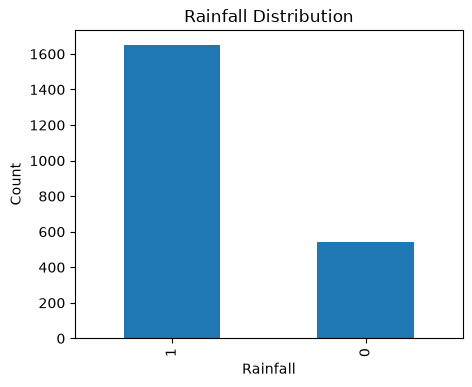

In [3]:
train["rainfall"].value_counts().plot(
    kind="bar",
    figsize=(5,4),
    title="Rainfall Distribution"
)

plt.xlabel("Rainfall")
plt.ylabel("Count")
plt.show()

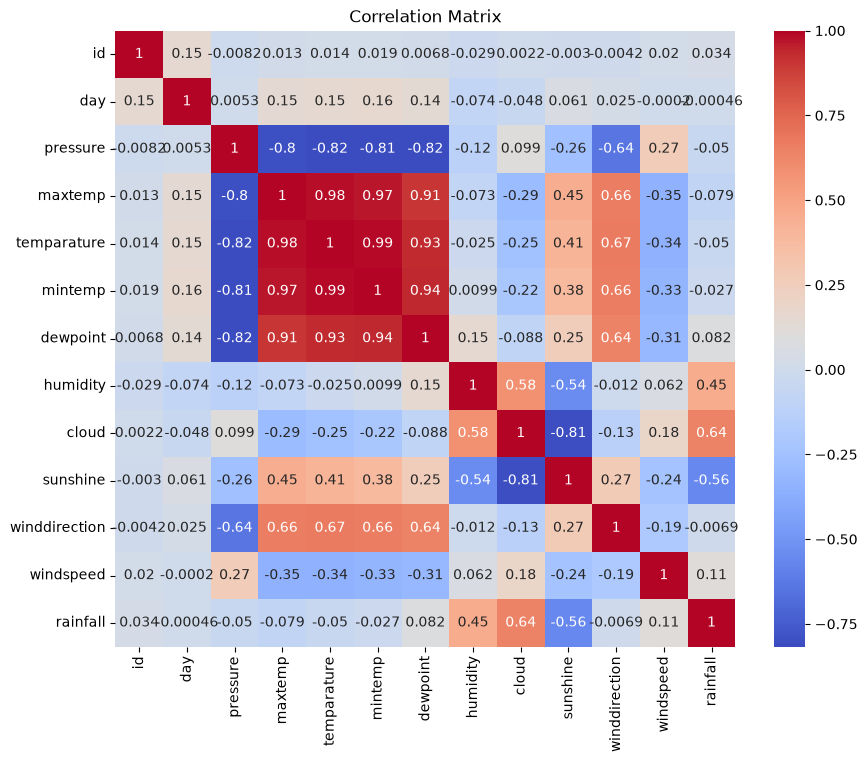

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    train.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

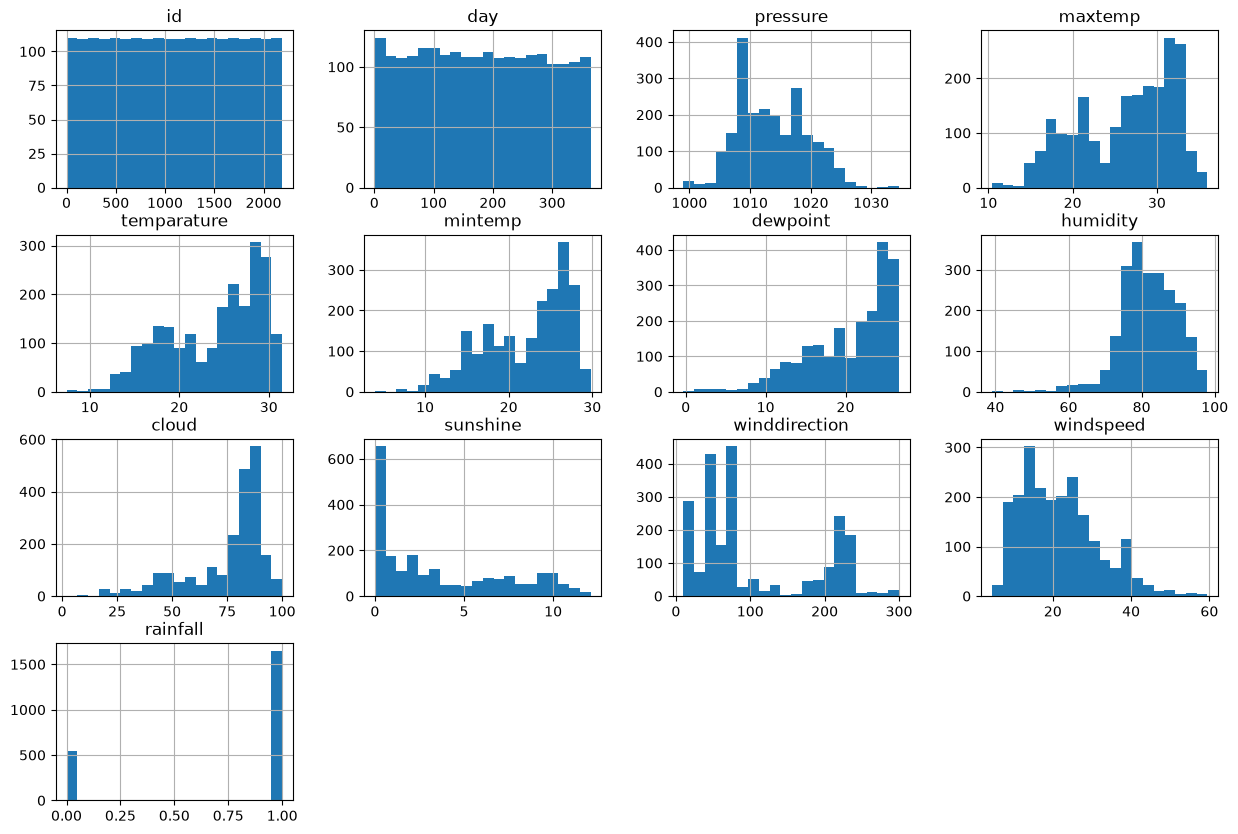

In [4]:
train.hist(
    figsize=(15,10),
    bins=20
)

plt.show()

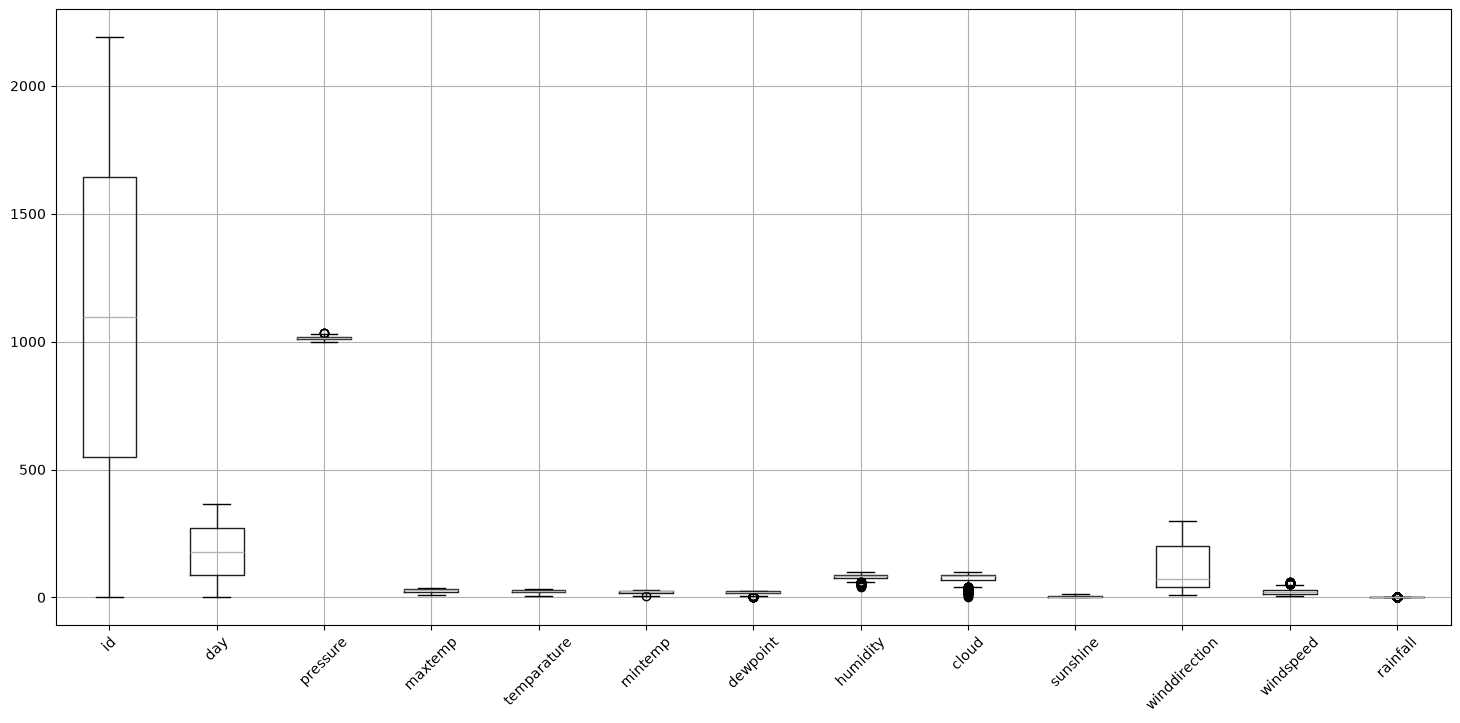

In [5]:
train.boxplot(
    figsize=(18,8)
)

plt.xticks(rotation=45)

plt.show()

In [9]:
train.corr()["rainfall"].sort_values(ascending=False)

rainfall         1.000000
cloud            0.641191
humidity         0.454213
windspeed        0.111625
dewpoint         0.081965
id               0.033674
day             -0.000462
winddirection   -0.006939
mintemp         -0.026841
temparature     -0.049660
pressure        -0.049886
maxtemp         -0.079304
sunshine        -0.555287
Name: rainfall, dtype: float64

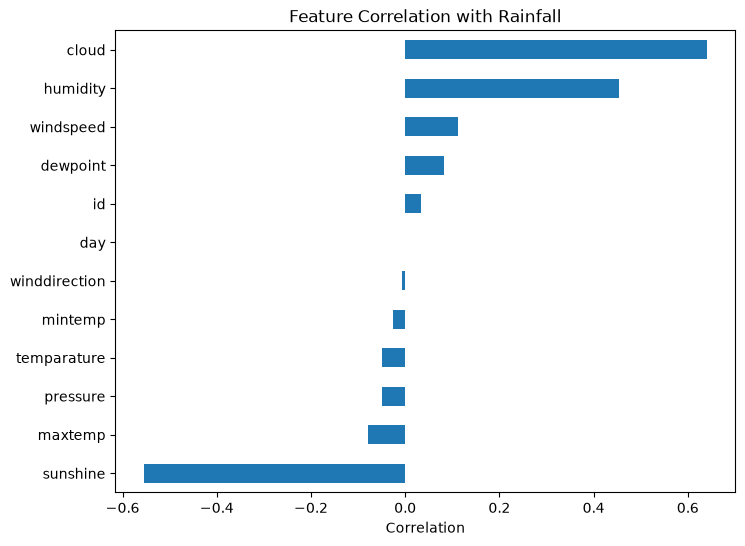

In [10]:
plt.figure(figsize=(8,6))

train.corr()["rainfall"][:-1].sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Rainfall")
plt.xlabel("Correlation")
plt.show()

In [8]:
X = train.drop(columns=["id", "rainfall"])
y = train["rainfall"]

print(X.shape)
print(y.shape)

(2190, 11)
(2190,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1752, 11)
(438, 11)


In [10]:
# Train Random Forest model

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model training completed!")

✅ Model training completed!


In [11]:
# Predict on test dataset

y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


In [12]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 0.8402
Accuracy: 84.02%


In [13]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.59      0.67       119
           1       0.86      0.93      0.89       319

    accuracy                           0.84       438
   macro avg       0.81      0.76      0.78       438
weighted avg       0.83      0.84      0.83       438



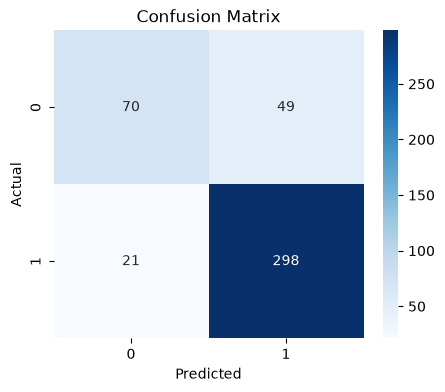

In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [2]:
# Feature Importance

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.ylabel("Importance Score")

plt.show()

importance

NameError: name 'pd' is not defined

In [25]:
# Save trained model

joblib.dump(model, "../models/rainfall_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [26]:
# Load Kaggle test dataset

test = pd.read_csv("../../dataset/test.csv")

test.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [27]:
X_kaggle = test.drop(columns=["id"])

In [28]:
kaggle_predictions = model.predict(X_kaggle)

kaggle_predictions[:10]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [29]:
submission = pd.DataFrame({
    "id": test["id"],
    "rainfall": kaggle_predictions
})

submission.head()

,id,rainfall
0,2190,1
1,2191,1
2,2192,1
3,2193,0
4,2194,0


In [30]:
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv created successfully!")

✅ submission.csv created successfully!
